# 01 - Data Exploration

Loads the raw India (Maharashtra) and Thailand GeoJSON files, profiles their schemas, checks the segment-ID join between them, and flags two known data anomalies (speed gap vs. `PercentOverLimit`, and very long segments).

In [1]:
import sys
sys.path.insert(0, '..')

import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd

from src.utils import load_geojson, detect_country, harmonize_schema

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

FILES = [
    '../data/raw/ADB_Innovation_Thailand.geojson',
    '../data/raw/ADB_Innovation_Maharashtra.geojson',
]
KEY_FIELDS = [
    'F85thPercentileSpeed', 'SpeedLimit', 'Sample_Size_Total', 'SampleSize_avg',
    'RoadLength', 'UrbanPC', 'PercentOverLimit', 'RankedPercentile',
]

## Load and profile each file

Note: the two files use **different schemas**. Thailand's columns match the Agilysis data-guide PDF (`RoadClass`, `SampleSizeTotal`); Maharashtra's match the field list in the challenge brief (`DISSOLVE_ID`, `class`, `UrbanPC`, `Sample_Size_Total`). `harmonize_schema` reconciles both onto a common set of columns.

In [2]:
raw_frames, harmonized_frames = [], []
for path in FILES:
    print('=' * 100)
    print('FILE:', path)
    gdf = load_geojson(path)
    country = detect_country(gdf)
    print(f'segments: {len(gdf)}   CRS: {gdf.crs}   detected country: {country}')
    print('\ncolumns and dtypes:'); print(gdf.dtypes)
    print('\nnull counts:'); print(gdf.isna().sum())
    print('\nfirst 3 rows:'); display(gdf.head(3))
    present = [f for f in KEY_FIELDS if f in gdf.columns]
    sl = gdf.copy()
    if 'SpeedLimit' in sl.columns:
        sl['SpeedLimit'] = pd.to_numeric(sl['SpeedLimit'], errors='coerce')
    print('\nsummary statistics for key fields:'); display(sl[present].describe())
    hgdf = harmonize_schema(gdf, country)
    raw_frames.append(gdf)
    harmonized_frames.append(hgdf)

FILE: ../data/raw/ADB_Innovation_Thailand.geojson


segments: 55884   CRS: EPSG:4326   detected country: Thailand

columns and dtypes:
OBJECTID                    int32
english_ro                    str
OvertureID                  int32
SampleSize_avg            float64
RoadLength                float64
WeightedSample            float64
Percent_                  float64
Percentile                float64
SpeedLimit                float64
RoadClass                     str
NumberOverLimit           float64
MedianSpeed               float64
F85thPercentileSpeed      float64
ForAnalysis               float64
ProvinceID                    str
SpeedLimitFloor           float64
PercentOverLimit          float64
InvPercentile             float64
AnalysisStatus                str
RankedPercentile          float64
StreetImageLink               str
LandUse                       str
NO_OF_Result_Segments     float64
PercentileBand                str
SampleSizeTotal           float64
Shape_Length              float64
geometry                 geometry

,OBJECTID,english_ro,OvertureID,SampleSize_avg,RoadLength,WeightedSample,Percent_,Percentile,SpeedLimit,RoadClass,NumberOverLimit,MedianSpeed,F85thPercentileSpeed,ForAnalysis,ProvinceID,SpeedLimitFloor,PercentOverLimit,InvPercentile,AnalysisStatus,RankedPercentile,StreetImageLink,LandUse,NO_OF_Result_Segments,PercentileBand,SampleSizeTotal,Shape_Length,geometry
0,1,Surin Ring Road,1,NaN,4.632086,NaN,NaN,NaN,NaN,primary,NaN,NaN,NaN,NaN,32,NaN,NaN,NaN,Not Included,NaN,"103.4699393,14.839138,103.43891053,14.86699584",NaN,NaN,NaN,NaN,4632.086492,"LINESTRING (103.46994 14.83914, 103.46967 14.8..."
1,2,Surin Ring Road,2,44479.6,2.300000,102303.08,0.000002,0.002591,66.0,primary,128017.0,78.38,115.2,66.0,32,60.0,0.575621,0.997409,Valid,26.253458,"103.43891053,14.86699584,103.48332214,14.94166589",RURAL,1.0,0-5%,222398.0,11672.918346,"LINESTRING (103.43891 14.867, 103.4383 14.8677..."
2,3,Surin Ring Road,3,NaN,0.122010,NaN,NaN,NaN,NaN,primary,NaN,NaN,NaN,NaN,32,NaN,NaN,NaN,Not Included,NaN,"103.48332214,14.94166589,103.48440114,14.94199564",NaN,NaN,NaN,NaN,122.010111,"LINESTRING (103.48332 14.94167, 103.48405 14.9..."



summary statistics for key fields:


,F85thPercentileSpeed,SpeedLimit,SampleSize_avg,RoadLength,PercentOverLimit,RankedPercentile
count,11544.000000,11596.000000,1.154400e+04,55884.000000,11544.000000,11544.000000
mean,78.281600,80.533374,6.697560e+05,1.374297,0.218104,49.900588
std,23.803171,18.436250,2.976403e+06,4.605329,0.246957,28.808870
min,0.000000,0.000000,3.333333e+00,0.000000,0.000000,0.008645
25%,67.000000,80.000000,6.813529e+04,0.029177,0.000000,24.954616
50%,82.000000,85.000000,1.772380e+05,0.159897,0.125001,49.900588
75%,94.500000,90.000000,4.455252e+05,0.786604,0.374999,74.846559
max,150.000000,120.000000,9.031018e+07,146.600000,1.000000,99.792531


FILE: ../data/raw/ADB_Innovation_Maharashtra.geojson


segments: 14082   CRS: EPSG:4326   detected country: India

columns and dtypes:
OBJECTID                   int32
DISSOLVE_ID                  str
class                        str
subtype                      str
names_primary                str
UrbanPC                  float64
SampleSize_avg           float64
RoadLength               float64
WeightedSample           float64
Percent_                 float64
Percentile               float64
SpeedLimit                   str
RoadClass                    str
LandUse                      str
NumberOverLimit          float64
MedianSpeed              float64
F85thPercentileSpeed     float64
Pass                     float64
ExcludeFromSpeedSPI      float64
PercentileBand               str
RankedPercentile         float64
Sample_Size_Total        float64
SpeedLimitFloor          float64
PercentOverLimit         float64
AnalysisStatus               str
StreetImageLink              str
Shape_Length             float64
geometry                geome

,OBJECTID,DISSOLVE_ID,class,subtype,names_primary,UrbanPC,SampleSize_avg,RoadLength,WeightedSample,Percent_,Percentile,SpeedLimit,RoadClass,LandUse,NumberOverLimit,MedianSpeed,F85thPercentileSpeed,Pass,ExcludeFromSpeedSPI,PercentileBand,RankedPercentile,Sample_Size_Total,SpeedLimitFloor,PercentOverLimit,AnalysisStatus,StreetImageLink,Shape_Length,geometry
0,1,SE/4183,secondary,road,NaN,0.0,0.0,5.872279,0.000000,0.000000e+00,0.000000e+00,NaN,secondary,RURAL,0.0,0.0,0.0,1.0,1.0,0-5%,0.000249,0.0,NaN,0.0,Valid,"73.5544591,16.2774648,73.53445,16.2401913",5872.278972,"LINESTRING (73.55446 16.27746, 73.5543 16.2770..."
1,2,SE/6376,secondary,road,NaN,0.0,0.5,5.900951,2.950476,1.704414e-09,1.704414e-09,55,secondary,RURAL,0.0,18.0,18.0,1.0,0.0,0-5%,0.000499,1.0,55.0,0.0,Valid,"73.9651122,21.0463691,73.9910297,21.0647687",5900.951225,"LINESTRING (73.96511 21.04637, 73.96506 21.047..."
2,3,SE/8617,secondary,road,NaN,0.0,1.0,3.496819,3.496819,2.020023e-09,3.724438e-09,NaN,secondary,RURAL,0.0,23.5,27.0,1.0,1.0,0-5%,0.000748,2.0,NaN,0.0,Valid,"74.9005386,19.0351416,74.8847951,19.020001",3496.819447,"LINESTRING (74.90054 19.03514, 74.90002 19.034..."



summary statistics for key fields:


,F85thPercentileSpeed,SpeedLimit,Sample_Size_Total,SampleSize_avg,RoadLength,UrbanPC,PercentOverLimit,RankedPercentile
count,4010.000000,3577.000000,4.010000e+03,4.010000e+03,4010.000000,4010.000000,4010.000000,4010.000000
mean,57.121422,52.784456,6.159132e+05,1.051031e+05,10.791098,0.232874,0.294180,0.500125
std,19.337695,10.035825,3.560263e+06,3.858887e+05,13.427387,0.394153,0.303788,0.288711
min,0.000000,20.000000,0.000000e+00,0.000000e+00,0.550366,0.000000,0.000000,0.000249
25%,42.500000,55.000000,3.247500e+03,9.933125e+02,2.051475,0.000000,0.000000,0.250187
50%,54.500000,55.000000,2.286200e+04,7.857500e+03,6.255602,0.000000,0.183882,0.500125
75%,70.000000,55.000000,1.189975e+05,3.433700e+04,14.005562,0.321039,0.533264,0.750062
max,114.666667,80.000000,9.962653e+07,4.894736e+06,179.728021,1.000000,1.000000,1.000000


## Segment ID join check

The likely join key is `DISSOLVE_ID` or `OBJECTID`. Since the two files cover **different countries**, they are disjoint datasets to be stacked, not joined on a shared key — this check confirms that rather than assuming it.

In [3]:
th_ids = set(harmonized_frames[0]['segment_id'])
mh_ids = set(harmonized_frames[1]['segment_id'])
overlap = th_ids & mh_ids
print(f'Thailand unique segment_id (OBJECTID): {len(th_ids)}')
print(f'Maharashtra unique segment_id (DISSOLVE_ID): {len(mh_ids)}')
print(f'Overlapping IDs: {len(overlap)} ({len(overlap)/min(len(th_ids), len(mh_ids))*100:.2f}% of smaller set)')
print('Expected near-zero: different countries, not a real shared-segment join.')

combined = pd.concat(harmonized_frames, ignore_index=True)
combined = gpd.GeoDataFrame(combined, geometry='geometry', crs='EPSG:4326')

Thailand unique segment_id (OBJECTID): 55884
Maharashtra unique segment_id (DISSOLVE_ID): 14082
Overlapping IDs: 0 (0.00% of smaller set)
Expected near-zero: different countries, not a real shared-segment join.


## Distributions

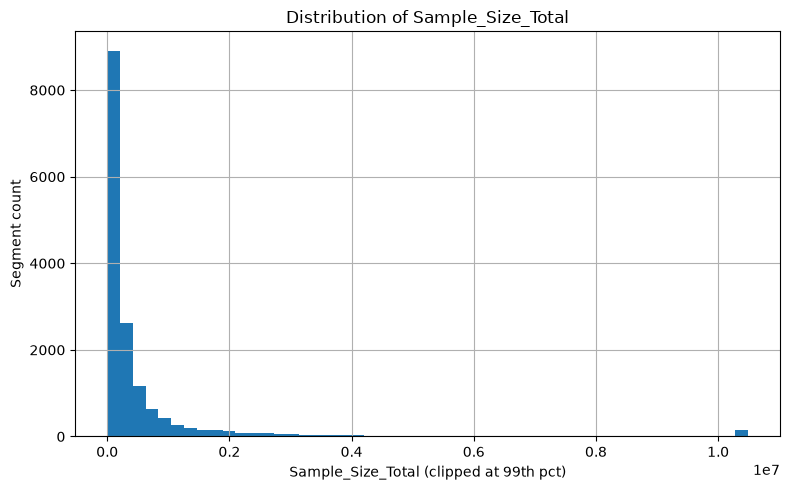

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
combined['Sample_Size_Total'].clip(upper=combined['Sample_Size_Total'].quantile(0.99)).hist(bins=50, ax=ax)
ax.set_xlabel('Sample_Size_Total (clipped at 99th pct)'); ax.set_ylabel('Segment count')
ax.set_title('Distribution of Sample_Size_Total')
fig.tight_layout(); fig.savefig('../outputs/sample_size_distribution.png', dpi=150)
plt.show()

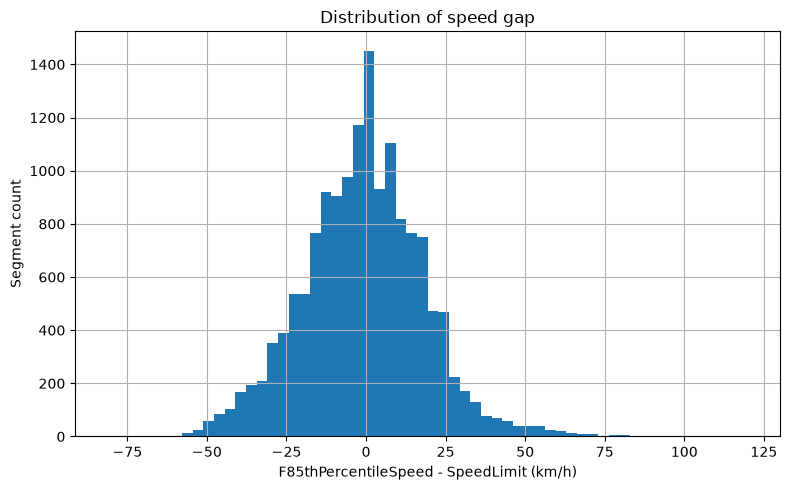

In [5]:
combined['speed_gap_raw'] = combined['F85thPercentileSpeed'] - combined['SpeedLimit']
fig, ax = plt.subplots(figsize=(8, 5))
combined['speed_gap_raw'].dropna().hist(bins=60, ax=ax)
ax.set_xlabel('F85thPercentileSpeed - SpeedLimit (km/h)'); ax.set_ylabel('Segment count')
ax.set_title('Distribution of speed gap')
fig.tight_layout(); fig.savefig('../outputs/speed_gap_distribution.png', dpi=150)
plt.show()

## Known anomaly: large speed gap but `PercentOverLimit == 0`

Flagged, not excluded — kept in the dataset with this caveat documented.

In [6]:
anomaly_mask = (combined['speed_gap_raw'] > 20) & (combined['PercentOverLimit'] == 0)
print(f"Segments flagged: {anomaly_mask.sum()} of {len(combined)} ({anomaly_mask.sum()/len(combined)*100:.2f}%)")
display(combined.loc[anomaly_mask, ['segment_id', 'country', 'road_class', 'SpeedLimit', 'F85thPercentileSpeed', 'PercentOverLimit']].head(10))

Segments flagged: 107 of 69966 (0.15%)


,segment_id,country,road_class,SpeedLimit,F85thPercentileSpeed,PercentOverLimit
56863,PR/3422,India,primary,20.0,48.000000,0.0
56997,TR/12489,India,trunk,20.0,65.000000,0.0
57164,TR/11931,India,trunk,20.0,84.500000,0.0
57167,PR/3307,India,primary,20.0,65.750000,0.0
57465,TR/11010,India,trunk,40.0,104.333333,0.0
57492,TR/11115,India,trunk,40.0,104.500000,0.0
57516,TR/11009,India,trunk,40.0,103.666667,0.0
57563,PR/1398,India,primary,20.0,58.300000,0.0
57593,TR/12416,India,trunk,40.0,76.000000,0.0
57713,TR/12353,India,trunk,20.0,55.500000,0.0


## Long segments (> 10km)

Per the Agilysis data guide, `RoadLength` should be ignored in favour of `Shape_Length` (they encode the same length, in km vs. metres respectively). `RoadLength_km` below is derived from `Shape_Length`.

In [7]:
long_mask = combined['RoadLength_km'] > 10
print(f"Segments flagged: {long_mask.sum()} of {len(combined)} ({long_mask.sum()/len(combined)*100:.2f}%)")

Segments flagged: 3775 of 69966 (5.40%)
